# Рекомендательная система для книг

На данных Goodbooks-10k исследуем оценки и теги книг, построим рекомендации
по среднему рейтингу, контентную модель, Item-Based CF и SVD.
В конце сравним три модели по качеству топ-5 рекомендаций на одном разбиении данных.

Запускайте ячейки последовательно. Библиотеки перечислены в `requirements.txt`.
Данные загружаются в папку `data`, если нужных CSV ещё нет.

## 1. Загрузка и исследование данных

### 1.1. Загрузка таблиц

In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split
from threadpoolctl import threadpool_limits
from wordcloud import WordCloud

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [2]:
path = Path("data")
required_files = ["books.csv", "ratings.csv", "book_tags.csv", "tags.csv", "to_read.csv"]
if not all((path / name).is_file() for name in required_files):
    kagglehub.dataset_download("zygmunt/goodbooks-10k", output_dir=str(path))

datasets = {name.removesuffix(".csv"): pd.read_csv(path / name) for name in required_files}
df_books = datasets["books"]
df_ratings = datasets["ratings"]
df_book_tags = datasets["book_tags"]
df_tags = datasets["tags"]
df_to_read = datasets["to_read"]

### 1.2. Качество данных и идентификаторы

`books` содержит описание книг, `ratings` — оценки, `tags` — названия тегов,
`book_tags` — связи книг с тегами, `to_read` — списки «хочу прочитать».
Последнюю таблицу исследуем, но в обучение по явным оценкам не включаем.

В этой версии датасета **`ratings.book_id` соответствует `books.id`**,
а `book_tags.goodreads_book_id` — столбцу `books.book_id`.
Поэтому после объединения тегов используем `books.id` как единый идентификатор
книги во всех моделях. Числовое совпадение двух разных ID не означает одну и ту же книгу.

In [3]:
for name, dataset in datasets.items():
    display(Markdown(f"**{name}: {len(dataset):,} строк, {dataset.shape[1]} столбцов**"))
    display(dataset.head(3))

quality = pd.DataFrame({
    name: {"Пропущено значений": data.isna().sum().sum(),
           "Полных дубликатов": data.duplicated().sum()}
    for name, data in datasets.items()
}).T
display(quality)
display(df_books.isna().sum().loc[lambda counts: counts > 0].rename("Пропуски в books"))
print("Повторных пар пользователь — книга:", df_ratings.duplicated(["user_id", "book_id"]).sum())

Повторных пар пользователь — книга: 2278


**books: 10,000 строк, 23 столбцов**

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,title,language_code,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,"Twilight (Twilight, #1)",en-US,3.57,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...


**ratings: 981,756 строк, 3 столбцов**

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5


...

,tag_id,tag_name
0,0,-
1,1,--1-
2,2,--10-


**to_read: 912,705 строк, 2 столбцов**

,user_id,book_id
0,1,112
1,1,235
2,1,533


,Пропущено значений,Полных дубликатов
books,2975,0
ratings,0,1644
book_tags,0,6
tags,0,0
to_read,0,0


isbn                          700
isbn13                        585
original_publication_year      21
original_title                585
language_code                1084
Name: Пропуски в books, dtype: int64

Пропуски в `original_title` заполняем из `title`. ISBN, язык и год издания в моделях
не используются, поэтому восстанавливать их не требуется.
Повторные пары «пользователь — книга» объединяем средней оценкой: это учитывает
различающиеся оценки и не позволяет одной паре попасть одновременно в train и test.
Средние оценки таких пар могут быть дробными.

In [4]:
df_books["original_title"] = df_books["original_title"].fillna(df_books["title"])
ratings = df_ratings.groupby(["user_id", "book_id"], as_index=False)["rating"].mean()
catalog = df_books.set_index("id").sort_index()
book_columns = ["original_title", "authors", "average_rating", "ratings_count"]
print(f"После объединения: {len(ratings):,} оценок, "
      f"{ratings.user_id.nunique():,} пользователей, {ratings.book_id.nunique():,} книг")

После объединения: 979,478 оценок, 53,424 пользователей, 10,000 книг


### 1.3. Распределение оценок

Показываем исходные целочисленные оценки до усреднения повторных пар.

Доля оценок 4 и 5: 66.2%


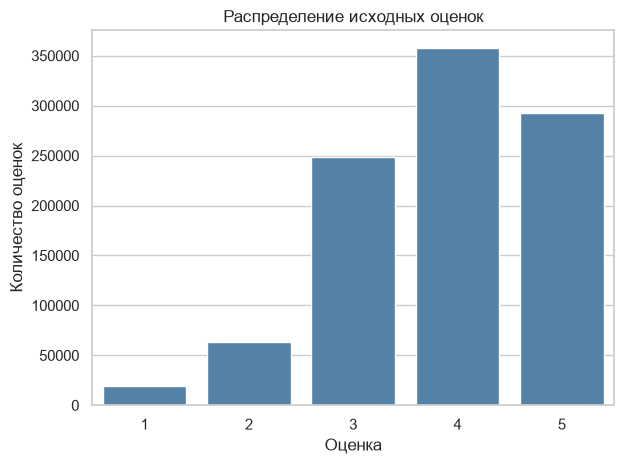

In [5]:
rating_counts = df_ratings["rating"].value_counts().sort_index()
sns.barplot(x=rating_counts.index, y=rating_counts.values, color="steelblue")
plt.xlabel("Оценка")
plt.ylabel("Количество оценок")
plt.title("Распределение исходных оценок")
plt.tight_layout()
plt.show()
print(f"Доля оценок 4 и 5: {df_ratings.rating.ge(4).mean():.1%}")

**Вывод.** Оценки смещены в положительную сторону: 66,2% исходных оценок — 4 и 5.
Поэтому невысокая ошибка прогноза оценки сама по себе ещё не означает, что модель
хорошо выбирает небольшое число интересных книг. Для этого отдельно нужны метрики топ-N.

### 1.4. Активность пользователей и популярность книг

Пользователи с 1–5 книгами: 20,985 (39.3%)
90-й процентиль активности: 47 оценок
Книги с не более чем 40 оценками: 5
90-й процентиль популярности: 100 оценок
Заполненность матрицы оценок: 0.183%


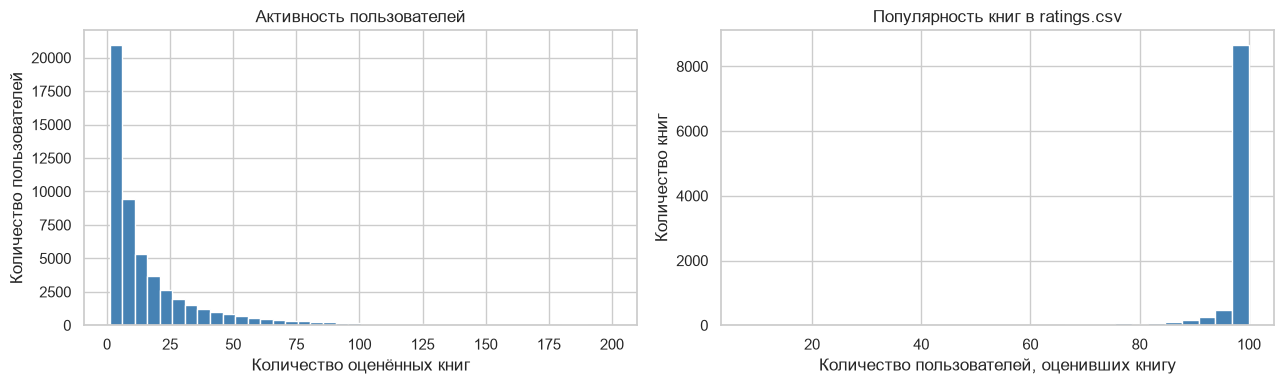

,Оценок на книгу
count,10000.000000
mean,97.947800
std,5.759322
min,8.000000
25%,99.000000
50%,100.000000
75%,100.000000
max,100.000000


In [6]:
user_activity = ratings.groupby("user_id").size()
book_activity = ratings.groupby("book_id").size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(user_activity, bins=40, color="steelblue")
axes[0].set(xlabel="Количество оценённых книг", ylabel="Количество пользователей",
            title="Активность пользователей")
axes[1].hist(book_activity, bins=30, color="steelblue")
axes[1].set(xlabel="Количество пользователей, оценивших книгу", ylabel="Количество книг",
            title="Популярность книг в ratings.csv")
plt.tight_layout()
plt.show()

active_threshold = user_activity.quantile(0.9)
popular_threshold = book_activity.quantile(0.9)
print(f"Пользователи с 1–5 книгами: {user_activity.le(5).sum():,} ({user_activity.le(5).mean():.1%})")
print(f"90-й процентиль активности: {active_threshold:g} оценок")
print(f"Книги с не более чем 40 оценками: {book_activity.le(40).sum():,}")
print(f"90-й процентиль популярности: {popular_threshold:g} оценок")
print(f"Заполненность матрицы оценок: {len(ratings) / (len(user_activity) * len(book_activity)):.3%}")
display(book_activity.describe().to_frame("Оценок на книгу"))

**Вывод.** У 39,3% пользователей не более пяти оценённых книг, а заполненность матрицы
составляет всего 0,183%. Истории многих пользователей короткие.
Для таких пользователей коллаборативной модели сложнее найти надёжных соседей.
Число оценок в `ratings.csv` описывает только доступную выборку;
оно отличается от `books.ratings_count`, содержащего агрегированную статистику Goodreads.
В очищенной выборке медиана и максимум числа оценок на книгу равны 100.
Поэтому число голосов слабо различает популярность большинства книг в этой выборке.
Порог активности считаем по всем пользователям, а не по уникальным значениям количества оценок.

### 1.5. Частые теги

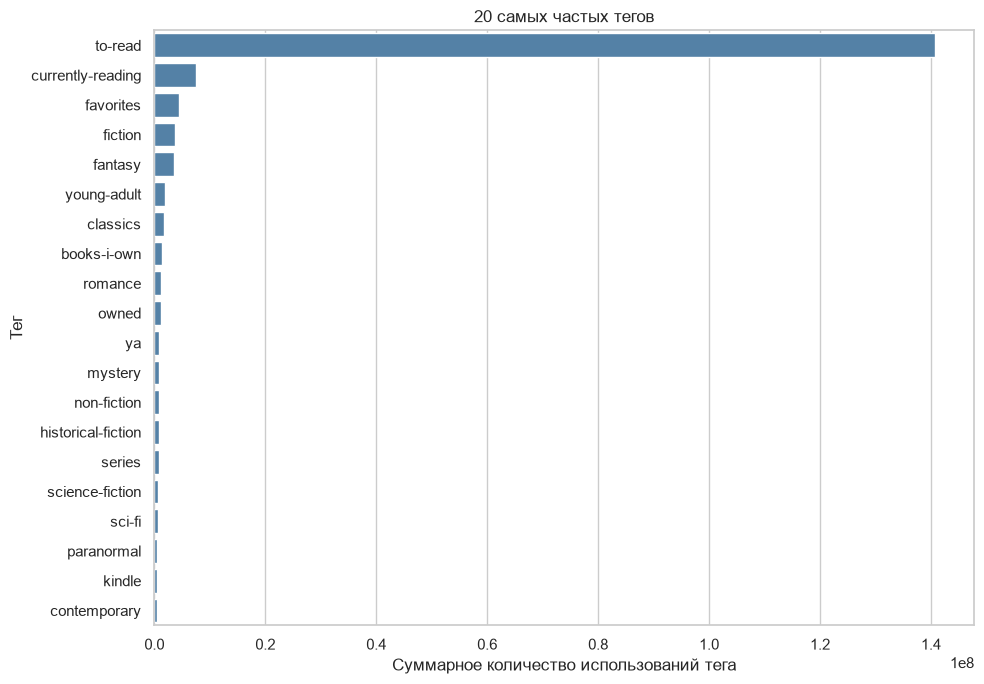

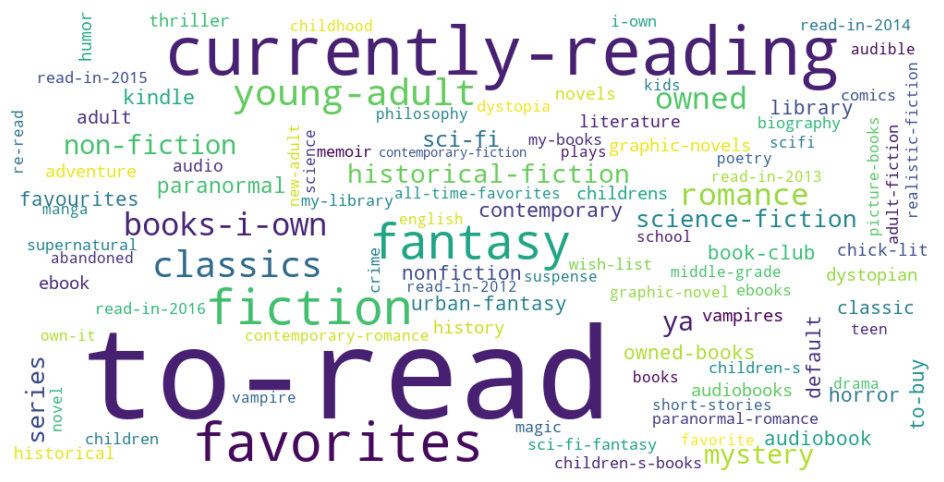

In [7]:
named_tags = df_book_tags.merge(df_tags, on="tag_id", how="left")
top_tags = named_tags.groupby("tag_name")["count"].sum().nlargest(100)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_tags.head(20).values, y=top_tags.head(20).index, color="steelblue")
plt.xlabel("Суммарное количество использований тега")
plt.ylabel("Тег")
plt.title("20 самых частых тегов")
plt.tight_layout()
plt.show()

wordcloud = WordCloud(width=1000, height=500, background_color="white",
                      random_state=RANDOM_STATE).generate_from_frequencies(top_tags.to_dict())
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

**Вывод.** Среди частых тегов встречаются не только жанры, но и пользовательские
полки, например `to-read`. Они описывают способ хранения книги в списках, а не её сюжет.
TF-IDF уменьшает вес распространённых слов, но полностью такой шум не устраняет.
В этой простой модели сохраняем все теги; их очистка — возможное дальнейшее улучшение.

## 2. Базовая и контентная модели

### 2.1. Рекомендации по среднему рейтингу

`recommend_popular` сначала отбирает книги с числом оценок не ниже порога,
затем сортирует по среднему рейтингу. При равном рейтинге выше стоит книга
с большим числом оценок. Возвращается список внутренних ID в порядке рекомендации.
Порог уменьшает влияние книг с малым числом голосов, но не делает рекомендации персональными.
Это демонстрация на агрегатах Goodreads, а не модель для честной оценки на holdout.

In [8]:
def recommend_popular(books, min_ratings=1000, n=10):
    """Вернуть ID книг с высоким средним рейтингом и достаточным числом оценок."""
    candidates = books.loc[books["ratings_count"] >= min_ratings]
    return candidates.sort_values(
        ["average_rating", "ratings_count"], ascending=False
    ).head(n).index.tolist()

recommended_ids = recommend_popular(catalog)
display(catalog.loc[recommended_ids, book_columns])

,original_title,authors,average_rating,ratings_count
id,,,,
3628,The Complete Calvin and Hobbes,Bill Watterson,4.82,28900
862,Words of Radiance,Brandon Sanderson,4.77,73572
3275,"Harry Potter Boxed Set, Books 1-5 (Harry Potte...","J.K. Rowling, Mary GrandPré",4.77,33220
8854,Mark of the Lion Trilogy,Francine Rivers,4.76,9081
7947,ESV Study Bible,"Anonymous, Lane T. Dennis, Wayne A. Grudem",4.76,8953
4483,It's a Magical World: A Calvin and Hobbes Coll...,Bill Watterson,4.75,22351
422,Complete Harry Potter Boxed Set,J.K. Rowling,4.74,190050
6361,There's Treasure Everywhere: A Calvin and Hobb...,Bill Watterson,4.74,16766
3753,"Harry Potter Collection (Harry Potter, #1-6)",J.K. Rowling,4.73,24618


**Вывод.** Такая выдача одинакова для всех пользователей и подходит как стартовый
вариант без истории чтения. Высокий средний рейтинг не гарантирует разнообразия:
несколько книг одного автора или серии могут занять значительную часть списка.

### 2.2. Похожие книги по TF-IDF

Для каждой книги объединяем название и её теги в один текстовый профиль.
При объединении используем Goodreads ID, после чего сохраняем внутренний ID `id`.
Частота `count` в этом варианте не используется: названия тегов объединяются
без повторения пропорционально числу их использований.

`TfidfVectorizer.fit_transform` разбивает профили на слова, приводит их к нижнему
регистру, удаляет английские стоп-слова и оставляет не более 20 000 признаков.
Вес слова растёт с его частотой в профиле и уменьшается, если оно встречается
во многих книгах. Полученные векторы нормируются по L2. Дефисы разделяют слова,
поэтому тег из нескольких слов не сохраняется как один отдельный признак.

`get_similar_books` находит строку исходной книги, вычисляет косинусное сходство
её вектора со всеми профилями, исключает саму книгу и выбирает максимальные значения.
Косинус — скалярное произведение векторов, делённое на произведение их длин;
для этих неотрицательных векторов он лежит от 0 до 1. Это сходство текстов, не вероятность интереса.
Вычисляем одну строку сходств по запросу, чтобы не хранить полную матрицу 10 000 × 10 000.

In [9]:
tags_by_book = named_tags.groupby("goodreads_book_id")["tag_name"].agg(" ".join)
profiles = df_books[["id", "book_id", "original_title"]].copy()
profiles["text"] = (profiles["original_title"] + " "
                    + profiles["book_id"].map(tags_by_book).fillna(""))
profile_positions = pd.Series(np.arange(len(profiles)), index=profiles["id"])

tfidf = TfidfVectorizer(stop_words="english", max_features=20_000)
tfidf_matrix = tfidf.fit_transform(profiles["text"])
print("Размерность TF-IDF:", tfidf_matrix.shape)


def get_similar_books(book_id, n=5):
    """Вернуть ID похожих книг; book_id — внутренний ID, n — положительное число."""
    position = profile_positions.loc[book_id]
    scores = cosine_similarity(tfidf_matrix[position], tfidf_matrix).ravel()
    scores[position] = -np.inf
    nearest = np.argsort(-scores, kind="stable")[:n]
    return profiles.iloc[nearest]["id"].tolist()


example_book = int(df_books.iloc[10]["id"])
print("Похожие на:", catalog.loc[example_book, "original_title"])
display(catalog.loc[get_similar_books(example_book, n=10), book_columns])

Размерность TF-IDF: (10000, 20000)
Похожие на: The Kite Runner 


,original_title,authors,average_rating,ratings_count
id,,,,
67,A Thousand Splendid Suns,Khaled Hosseini,4.34,818742
359,And The Mountains Echoed,Khaled Hosseini,4.03,199326
28,Lord of the Flies,William Golding,3.64,1605019
8,The Catcher in the Rye,J.D. Salinger,3.79,2044241
5,The Great Gatsby,F. Scott Fitzgerald,3.89,2683664
595,A Separate Peace,John Knowles,3.56,155901
4,To Kill a Mockingbird,Harper Lee,4.25,3198671
90,The Outsiders,S.E. Hinton,4.06,659248
417,The Thirteenth Tale,Diane Setterfield,3.95,213200


**Вывод.** Контентная модель находит книги с похожими названиями и тегами без истории
оценок пользователя. Она полезна для запроса «что почитать похожего», но не учитывает
индивидуальный вкус и зависит от качества тегов. Сходство примеров не заменяет измерение качества.

## 3. Коллаборативная фильтрация

### 3.1. Общее разбиение и матрица взаимодействий

Отделяем 20% уникальных пар для теста с `random_state=42`.
Временных меток нет, поэтому разбиение случайное, а не хронологическое.
Все модели, участвующие в итоговом сравнении, используют только это обучение.

`csr_matrix` хранит только ненулевые значения и их позиции. Строка соответствует
пользователю, столбец — книге, значение — оценке. Ноль означает отсутствие оценки,
а не недовольство книгой. Это позволяет обойтись без плотной матрицы пользователей и книг.
Косинусное сходство вычисляем между столбцами — книгами с похожими профилями оценок.
Матрица сходств книг остаётся плотной и занимает около 400 МБ при `float32`.

In [10]:
data = Dataset.load_from_df(ratings[["user_id", "book_id", "rating"]], Reader(rating_scale=(1, 5)))
trainset, testset = train_test_split(data, test_size=0.2, random_state=RANDOM_STATE)
rating_columns = ["user_id", "book_id", "rating"]
train_df = pd.DataFrame(trainset.build_testset(), columns=rating_columns)
test_df = pd.DataFrame(testset, columns=rating_columns)

book_ids = catalog.index.to_numpy()
user_ids = np.sort(train_df.user_id.unique())
item_index = pd.Index(book_ids)
user_index = pd.Index(user_ids)
interaction_matrix = csr_matrix(
    (train_df.rating.to_numpy(dtype=np.float32),
     (user_index.get_indexer(train_df.user_id), item_index.get_indexer(train_df.book_id))),
    shape=(len(user_ids), len(book_ids))
)
books_similarity = cosine_similarity(interaction_matrix.T)
np.fill_diagonal(books_similarity, 0)
item_means = train_df.groupby("book_id").rating.mean().reindex(book_ids).fillna(train_df.rating.mean()).to_numpy()

print(f"Train: {len(train_df):,}; test: {len(test_df):,}")
print("Размерность матрицы взаимодействий:", interaction_matrix.shape)
display(pd.DataFrame(interaction_matrix[:5, :10].toarray(), index=user_ids[:5], columns=book_ids[:10]))

Train: 783,582; test: 195,896
Размерность матрицы взаимодействий: (53041, 10000)


,1,2,3,4,5,6,7,8,9,10
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 3.2. Прогноз по похожим книгам

`item_cf_scores` возвращает прогноз сразу для всего каталога в порядке `book_ids`.

1. Берём только книги, оценённые пользователем в train, и его оценки этих книг.
2. Для каждого кандидата извлекаем сходство с этими книгами. Диагональ заранее
   обнулена, поэтому книга не служит соседом самой себе.
3. Считаем взвешенное среднее: сумма «сходство × оценка» делится на сумму сходств.
   Здесь используются все соседи с положительным сходством, без ограничения top-k.
4. Если сумма сходств равна нулю, используем среднюю оценку пользователя.
   Для неизвестного пользователя берём средние оценки книг, а для книги без оценок — среднее train.

В коде `weights @ history.data` вычисляет числители сразу для всех книг.
`np.divide(..., where=...)` оставляет запасной прогноз там, где делитель равен нулю.
Эта проверка необходима; проверки типов и параметров для учебных примеров не добавляем.
Метод использует исходные оценки без центрирования, поэтому учитывает и привычку пользователя
ставить в целом высокие или низкие оценки.

In [11]:
def item_cf_scores(user_id):
    """Взвешенные оценки всех книг по истории пользователя из train."""
    if user_id not in user_index:
        return item_means.copy()
    history = interaction_matrix.getrow(user_index.get_loc(user_id))
    weights = books_similarity[:, history.indices]
    weight_sums = weights.sum(axis=1)
    scores = np.full(len(book_ids), history.data.mean(), dtype=np.float32)
    return np.divide(weights @ history.data, weight_sums, out=scores, where=weight_sums > 0)


example_user = int(train_df.groupby("user_id").size().idxmax())
example_scores = item_cf_scores(example_user)
print(f"Пользователь {example_user}, книга: {catalog.loc[example_book, 'original_title']}")
print(f"Прогноз CF: {example_scores[item_index.get_loc(example_book)]:.2f}")

Пользователь 9668, книга: The Kite Runner 
Прогноз CF: 3.70


**Вывод.** CF даёт персональные прогнозы на основе оценок других читателей и не требует
текстовых описаний. При короткой истории или отсутствии общих читателей прогноз сводится
к средним значениям. Отдельный пример показывает работу функции, но не доказывает качество;
его измерим на отложенных взаимодействиях.

## 4. Матричное разложение SVD

Модель Surprise SVD приближает оценку формулой

$$\hat r_{ui} = \mu + b_u + b_i + p_u^T q_i.$$

Здесь μ — средняя оценка train, bᵤ и bᵢ — смещения пользователя и книги,
а pᵤ и qᵢ — обучаемые векторы скрытых предпочтений и свойств.
Это оптимизация по известным оценкам, а не обычное разложение заполненной нулями матрицы.
50 факторов задают размер векторов; 20 эпох — число проходов по train;
`lr_all` управляет шагом обучения, `reg_all` ограничивает величину параметров.
Параметры фиксированы и не подбираются по тестовой выборке.

RMSE сильнее штрафует большие ошибки, MAE показывает среднее абсолютное отклонение
в единицах шкалы оценок. Обе метрики считаются только по тестовым парам.

In [12]:
model = SVD(n_factors=50, n_epochs=20, lr_all=0.01, reg_all=0.02, random_state=RANDOM_STATE)
model.fit(trainset)
predictions = model.test(testset)
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

RMSE: 0.8477
MAE:  0.6564


### 4.1. Быстрый расчёт прогнозов SVD

`svd_scores` вычисляет ту же формулу сразу для всех книг вместо тысяч вызовов
`model.predict`. Внутренние номера Surprise зависят от порядка обучающих данных,
поэтому сначала переносим факторы и смещения в порядок нашего каталога.
Для книги или пользователя, отсутствовавших в train, соответствующие параметры
оставляем нулевыми: так сохраняется стандартное поведение Surprise.
Результат ограничиваем шкалой от 1 до 5, как и `model.predict`.

In [13]:
item_factors = np.zeros((len(book_ids), model.n_factors))
item_biases = np.zeros(len(book_ids))
for inner_id in trainset.all_items():
    position = item_index.get_loc(trainset.to_raw_iid(inner_id))
    item_factors[position] = model.qi[inner_id]
    item_biases[position] = model.bi[inner_id]
inner_users = {trainset.to_raw_uid(uid): uid for uid in trainset.all_users()}


def svd_scores(user_id):
    """Прогнозы SVD для всего каталога, включая неизвестных модели пользователей."""
    scores = trainset.global_mean + item_biases.copy()
    if user_id in inner_users:
        inner_user = inner_users[user_id]
        scores += model.bu[inner_user] + item_factors @ model.pu[inner_user]
    return np.clip(scores, 1, 5)

## 5. Сравнение топ-N рекомендаций

### 5.1. Протокол и ранжирование

Релевантны книги с тестовой оценкой не ниже 4. Кандидаты — **весь каталог** без книг,
оценённых пользователем в train. Метрики усредняем по пользователям хотя бы с одной
релевантной тестовой книгой. Число исключённых пользователей выводим отдельно.
Неизвестные интересы не считаются релевантными, поэтому оценка ограничена доступной историей.

Сравниваем Popularity (число оценок в train), Item-Based CF и SVD. Статистику
`books.average_rating` и `books.ratings_count` в этом сравнении не используем,
так как она не ограничена обучающей выборкой. Контентная модель решает отдельную
задачу сходства книг; для персонального сравнения ей понадобился бы профиль пользователя.

`top_items` сортирует прогнозы по убыванию, а при равенстве — по ID книги.
Затем исключает историю train и оставляет первые K книг. ID изначально уникальны,
поэтому повторно проверять выдачу на дубликаты не требуется.

In [14]:
K = 5
THRESHOLD = 4
train_user_items = train_df.groupby("user_id").book_id.agg(set).to_dict()
relevant_items = (test_df.loc[test_df.rating >= THRESHOLD]
                  .groupby("user_id").book_id.agg(set).to_dict())
test_users = sorted(relevant_items)
popularity_scores = train_df.groupby("book_id").size().reindex(book_ids, fill_value=0).to_numpy()
print(f"Пользователей для оценки: {len(test_users):,}")
print(f"Исключено без релевантных тестовых книг: {test_df.user_id.nunique() - len(test_users):,}")


def top_items(user_id, scores, k=K):
    """Выбрать top-k книг, которых нет в обучающей истории пользователя."""
    seen = train_user_items.get(user_id, set())
    order = np.argsort(-np.asarray(scores), kind="stable")
    return [book_id for book_id in book_ids[order] if book_id not in seen][:k]


recommended_ids = top_items(example_user, svd_scores(example_user))
display(catalog.loc[recommended_ids, book_columns])

Пользователей для оценки: 34,565
Исключено без релевантных тестовых книг: 5,785


,original_title,authors,average_rating,ratings_count
id,,,,
21,Harry Potter and the Order of the Phoenix,"J.K. Rowling, Mary GrandPré",4.46,1735368
24,Harry Potter and the Goblet of Fire,"J.K. Rowling, Mary GrandPré",4.53,1753043
30,Gone Girl,Gillian Flynn,4.03,512475
57,The Secret Life of Bees,Sue Monk Kidd,4.01,916189
63,Wuthering Heights,"Emily Brontë, Richard J. Dunn",3.82,899195


### 5.2. Как считаются метрики

`ranking_metrics` сопоставляет рекомендации с множеством релевантных тестовых книг.
Массив `hits` содержит 1 на месте попадания и 0 на месте промаха.

- **Precision@K** — число попаданий, делённое на K. Если список короче K,
  отсутствующие позиции тоже считаются промахами.
- **Recall@K** — число попаданий, делённое на число всех релевантных тестовых книг пользователя.
- **nDCG@K** учитывает порядок: попадание на позиции j получает вес 1 / log₂(j + 1),
  где позиции начинаются с 1. Сумму весов делим на идеальную сумму для
  min(K, число релевантных книг) попаданий на первых позициях.

Чем выше эти метрики, тем лучше. Пользователи без релевантных книг исключены заранее,
поэтому знаменатели Recall и nDCG не равны нулю.

`evaluate` получает функцию расчёта прогнозов, строит выдачу для каждого тестового
пользователя и усредняет три метрики с одинаковым весом пользователей.
Хранить рекомендации всех моделей одновременно не нужно. Один поток BLAS снижает
накладные расходы при большом числе небольших матричных умножений.

In [15]:
def ranking_metrics(recommendations, relevant, k=K):
    """Precision, Recall и nDCG для одного пользователя."""
    hits = np.array([book_id in relevant for book_id in recommendations[:k]], dtype=float)
    precision = hits.sum() / k
    recall = hits.sum() / len(relevant)
    dcg = (hits / np.log2(np.arange(len(hits)) + 2)).sum()
    ideal_dcg = (1 / np.log2(np.arange(min(len(relevant), k)) + 2)).sum()
    return precision, recall, dcg / ideal_dcg


def evaluate(score_function, k=K):
    """Средние метрики по пользователям с релевантными тестовыми книгами."""
    metrics = []
    with threadpool_limits(limits=1):
        for user_id in test_users:
            recommendations = top_items(user_id, score_function(user_id), k)
            metrics.append(ranking_metrics(recommendations, relevant_items[user_id], k))
    return dict(zip([f"Precision@{k}", f"Recall@{k}", f"nDCG@{k}"], np.mean(metrics, axis=0)))

In [16]:
results = {}
for name, score_function in [
    ("Popularity", lambda user_id: popularity_scores),
    ("Item-Based CF", item_cf_scores),
    ("SVD", svd_scores),
]:
    print(f"Оценка {name}...", flush=True)
    results[name] = evaluate(score_function)

summary = pd.DataFrame(results).T
summary.index.name = "Модель"
display(summary.round(4))

Оценка Popularity...
Оценка Item-Based CF...
Оценка SVD...


,Precision@5,Recall@5,nDCG@5
Модель,,,
Popularity,0.0002,0.0001,0.0002
Item-Based CF,0.0002,0.0006,0.0004
SVD,0.0009,0.0009,0.0010


## 6. Выводы

In [17]:
best_model = summary[f"nDCG@{K}"].idxmax()
display(Markdown(
    f"На этом разбиении лучшая **nDCG@{K}** у **{best_model}**: "
    f"**{summary.loc[best_model, f'nDCG@{K}']:.4f}**. "
    f"Её Precision@{K} = {summary.loc[best_model, f'Precision@{K}']:.4f}, "
    f"Recall@{K} = {summary.loc[best_model, f'Recall@{K}']:.4f}. "
    f"У SVD ошибка прогноза оценок: RMSE = **{rmse:.4f}**, MAE = **{mae:.4f}**."
))

На этом разбиении лучшая **nDCG@5** у **SVD**: **0.0010**. Её Precision@5 = 0.0009, Recall@5 = 0.0009. У SVD ошибка прогноза оценок: RMSE = **0.8477**, MAE = **0.6564**.

**Результат запуска.** SVD показала лучшие значения всех трёх метрик: Precision@5 ≈ 0,000880, Recall@5 ≈ 0,000912, nDCG@5 ≈ 0,001033. У Item-Based CF nDCG@5 ≈ 0,000407, у Popularity — ≈ 0,000164. При этом абсолютное качество низкое: Precision@5 у SVD составляет около 0,088%, то есть совпадения рекомендаций с известными релевантными тестовыми книгами редки. Считать такую выдачу практически качественной по этим результатам нельзя.

**Интерпретация.** MAE SVD ≈ 0,656 означает среднюю ошибку примерно на 0,66 балла, но это не превращается автоматически в хорошее ранжирование всего каталога. Короткие истории, небольшое число известных релевантных книг и почти одинаковое число оценок у большинства книг ограничивают этот эксперимент. Чтобы установить причины низких метрик, нужен отдельный анализ выдачи и групп пользователей.

1. Данные требуют согласования идентификаторов и объединения повторных оценок.
   Иначе можно рекомендовать другую книгу с совпавшим ID или получить утечку между train и test.
2. Рекомендации по среднему рейтингу просты и не требуют истории пользователя.
   TF-IDF решает задачу поиска похожих книг, но зависит от названий и качества тегов.
3. CF использует сходство читательских оценок, SVD — скрытые факторы предпочтений.
   Оба подхода персонализируют выдачу, но при недостатке истории вынуждены опираться на средние значения.
4. Ошибка оценки и качество топ-N отражают разные свойства модели. Итоговую выдачу
   сравниваем с Popularity на одном тесте; выбирать модель только по RMSE нельзя.
5. Результаты относятся к одному случайному разбиению и пользователям с релевантными
   тестовыми книгами. Они не доказывают качество для новых пользователей или будущего периода.
   Следующие шаги — отдельная валидация для подбора параметров, несколько разбиений,
   анализ коротких историй и оценка разнообразия рекомендаций.